In [1]:
from pathlib import Path

import torch
from datasets import load_dataset
from qwen_vl_utils import process_vision_info
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.8.0+cu126).


In [2]:
# MODEL_ID   = "Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4"
MODEL_ID   = "Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int8"
DATA_DIR   = Path("/workspace/latentlens/experiment/data/pixmo_cap_val100")
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

print(f"device : {DEVICE}")
print(f"data   : {DATA_DIR}")

device : cuda
data   : /workspace/latentlens/experiment/data/pixmo_cap_val100


Generating validation split: 0 examples [00:00, ? examples/s]

rows   : 100
columns: ['val_idx', 'image_url', 'caption', 'transcripts', 'image']

val_idx : 0
caption : This image showcases a detailed, aesthetic, top-down view of a wooden bowl filled to the brim with approximately one or ...


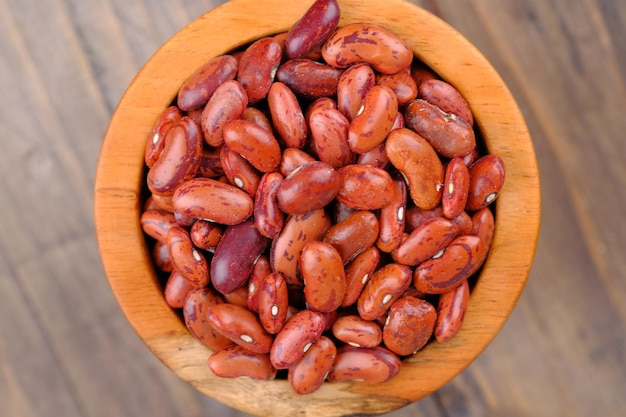

In [3]:
# Load the existing pixmo_cap_val100 dataset (same split used in 4_fp_baseline)
ds_val100 = load_dataset(
    "parquet",
    data_files={"validation": str(DATA_DIR / "data" / "validation-*.parquet")},
    split="validation",
)

print(f"rows   : {len(ds_val100)}")
print(f"columns: {ds_val100.column_names}")

# Grab the first example
example = ds_val100[0]
image   = example["image"]          # PIL Image already embedded in parquet
caption = example["caption"]
val_idx = example["val_idx"]

print(f"\nval_idx : {val_idx}")
print(f"caption : {caption[:120]}...")
image

In [4]:
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    attn_implementation="flash_attention_2",
    device_map="auto",
)
model.eval()

processor = AutoProcessor.from_pretrained(MODEL_ID)

print(f"model  : {MODEL_ID}")
print(f"dtype  : {next(model.parameters()).dtype}")

config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


INFO  

┌─────────────┐    ┌────────────────────────┐    ┌────────────┐    ┌─────────┐
│ GPT-QModel  │ -> │ ▓▓▓▓▓▓▓▓▓▓▓▓ 16bit     │ -> │ ▒▒▒▒ 8bit  │ -> │ ░░ 4bit │
└─────────────┘    └────────────────────────┘    └────────────┘    └─────────┘
GPT-QModel   : 7.1.0+b836749
Transformers : 5.4.0
Torch        : 2.8.0+cu126
Triton       : 3.4.0


...

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int8/resolve/main/special_tokens_map.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int8/0768122e31eb1dfe970d3910cb5aa5911be9e309/special_tokens_map.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int8/0768122e31eb1dfe970d3910cb5aa5911be9e309/special_tokens_map.json "HTTP/1.1 200 OK"


special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int8 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int8/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int8/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int8/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int8/0768122e31eb1dfe970d3910cb5aa5911be9e309/preprocessor_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int8/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7

model  : Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int8
dtype  : torch.float16


In [5]:
processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4")

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg",
            },
            {"type": "text", "text": "Describe this image."},
        ],
    }
]

# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cuda")

# Inference: Generation of the output
generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)

INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"


INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/dec510a35a3e9b6481b6427c7a08984df2402535/preprocessor_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/dec510a35a3e9b6481b6427c7a08984df2402535/preprocessor_config.json "HTTP/1.1 200 OK"


preprocessor_config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/dec510a35a3e9b6481b6427c7a08984df2402535/preprocessor_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/resolve/main/chat_template.json "HTTP/1.1 307 Temporary Redirect"

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/resolve/main/special_tokens_map.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/dec510a35a3e9b6481b6427c7a08984df2402535/special_tokens_map.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/dec510a35a3e9b6481b6427c7a08984df2402535/special_tokens_map.json "HTTP/1.1 200 OK"


special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/dec510a35a3e9b6481b6427c7a08984df2402535/preprocessor_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct-GPTQ-Int4/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7

["The image depicts a serene beach scene with a woman and her dog enjoying a moment together. The woman is sitting on the sand, facing the ocean, and appears to be engaging in a playful activity with her dog. The dog, which is a large breed, is sitting on its hind legs and extending its front paw towards the woman's hand, as if giving her a high-five. The woman is smiling and seems to be enjoying the interaction.\n\nThe woman is dressed in a casual outfit, wearing a plaid shirt and dark pants. She has long hair that falls over her shoulders. The dog is wearing a harness, suggesting that it is"]


In [6]:
generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)

["The image depicts a serene beach scene with a woman and her dog enjoying a moment together. The woman is sitting on the sand, facing the ocean, and appears to be engaging in a playful activity with her dog. The dog, which is a large breed, is sitting on its hind legs and extending its front paw towards the woman's hand, as if giving her a high-five. The woman is smiling and seems to be enjoying the interaction.\n\nThe woman is dressed in a casual outfit, wearing a plaid shirt and dark pants. She has long hair that falls over her shoulders. The dog is wearing a harness, suggesting that it is"]
